Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']
Initial rows: 45000
Target column: loan_status
Rows after target cleaning: 45000
Target distribution:
 loan_status
0    35000
1    10000
Name: count, dtype: int64
Categorical: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


/tmp/ipython-input-930598662.py:73: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-930598662.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin


Accuracy: 0.9292222222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000


Confusion Matrix:
 [[6832  168]
 [ 469 1531]]

Displaying SHAP Top Feature Importance


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [3]:
# ================================
# LOAN APPROVAL PREDICTION PROJECT
# FULL END-TO-END IMPLEMENTATION
# ================================

# ---------- 1. INSTALL & IMPORT ----------
!pip install -q shap scikit-learn joblib pandas numpy matplotlib

import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------- 2. LOAD DATASET ----------
# Upload loan_data.csv in Colab
df = pd.read_csv("loan_data.csv")

# ---------- 3. CLEAN COLUMN NAMES ----------
df.columns = df.columns.str.strip().str.lower()

print("Columns:", list(df.columns))
print("Initial rows:", len(df))

# ---------- 4. IDENTIFY TARGET COLUMN ----------
possible_targets = ["loan_status", "status", "approved", "approval", "target"]

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError("❌ Target column not found.")

print("Target column:", target_col)

# ---------- 5. CLEAN & MAP TARGET ----------
df[target_col] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

df[target_col] = df[target_col].map({
    "y": 1, "yes": 1, "approved": 1, "1": 1, "true": 1,
    "n": 0, "no": 0, "rejected": 0, "0": 0, "false": 0
})

df = df.dropna(subset=[target_col])

print("Rows after target cleaning:", len(df))
print("Target distribution:\n", df[target_col].value_counts())

# ---------- 6. HANDLE MISSING VALUES ----------
for col in df.columns:
    if col == target_col:
        continue
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# ---------- 7. FEATURE / TARGET SPLIT ----------
X = df.drop(target_col, axis=1)
y = df[target_col]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

print("Categorical columns:", list(cat_cols))
print("Numerical columns:", list(num_cols))

# ---------- 8. PREPROCESSING + MODEL PIPELINE ----------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=True), cat_cols)
    ]
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
])

# ---------- 9. TRAIN / TEST SPLIT ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y if y.nunique() > 1 else None
)

# ---------- 10. TRAIN MODEL ----------
pipeline.fit(X_train, y_train)

# ---------- 11. EVALUATION ----------
y_pred = pipeline.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ---------- 12. SHAP EXPLAINABILITY (FIXED) ----------
# Sample for speed
X_sample = X_train.sample(min(100, len(X_train)), random_state=42)

# Transform features
X_trans = pipeline.named_steps["preprocess"].transform(X_sample)
rf_model = pipeline.named_steps["model"]

# Get feature names
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][2]
ohe = preprocessor.transformers_[1][1]
cat_feature_names = ohe.get_feature_names_out(cat_features)

final_feature_names = list(num_features) + list(cat_feature_names)

# Convert transformed matrix to DataFrame
X_shap_df = pd.DataFrame(
    X_trans.toarray() if hasattr(X_trans, "toarray") else X_trans,
    columns=final_feature_names
)

# SHAP Explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_df)

# Handle SHAP output format safely
if isinstance(shap_values, list):
    shap_vals = shap_values[1]      # Approved class
else:
    shap_vals = shap_values[:, :, 1]

print("SHAP shape:", shap_vals.shape)
print("Feature matrix shape:", X_shap_df.shape)

# Plot SHAP summary
shap.summary_plot(
    shap_vals,
    X_shap_df,
    plot_type="bar",
    max_display=10
)

# ---------- 13. FAIRNESS QUICK-CHECK ----------
df["prediction"] = pipeline.predict(X)

for sensitive in ["gender", "education", "married"]:
    if sensitive in df.columns:
        print(f"\nApproval rate by {sensitive}:")
        print(df.groupby(sensitive)["prediction"].mean())

# ---------- 14. SAVE MODEL ----------
joblib.dump(pipeline, "loan_approval_model.pkl")
print("\n✅ Model saved as loan_approval_model.pkl")

# ---------- 15. DOWNLOAD MODEL (COLAB) ----------
from google.colab import files
files.download("loan_approval_model.pkl")

print("\n🎉 PROJECT EXECUTION COMPLETED SUCCESSFULLY")


Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']
Initial rows: 45000
Target column: loan_status
Rows after target cleaning: 45000
Target distribution:
 loan_status
0    35000
1    10000
Name: count, dtype: int64
Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [4]:
!pip install -q shap scikit-learn joblib pandas numpy matplotlib

In [5]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [6]:
df = pd.read_csv("loan_data.csv")

In [7]:
df.columns = df.columns.str.strip().str.lower()

print("Columns:", list(df.columns))
print("Initial rows:", len(df))

Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']
Initial rows: 45000


In [8]:
possible_targets = ["loan_status", "status", "approved", "approval", "target"]

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError("❌ Target column not found.")

print("Target column:", target_col)

Target column: loan_status


In [9]:
df[target_col] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

df[target_col] = df[target_col].map({
    "y": 1, "yes": 1, "approved": 1, "1": 1, "true": 1,
    "n": 0, "no": 0, "rejected": 0, "0": 0, "false": 0
})

df = df.dropna(subset=[target_col])

print("Rows after target cleaning:", len(df))
print("Target distribution:\n", df[target_col].value_counts())

Rows after target cleaning: 45000
Target distribution:
 loan_status
0    35000
1    10000
Name: count, dtype: int64


In [10]:
for col in df.columns:
    if col == target_col:
        continue
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [11]:
X = df.drop(target_col, axis=1)
y = df[target_col]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

print("Categorical columns:", list(cat_cols))
print("Numerical columns:", list(num_cols))

Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


In [13]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols)
    ]
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
])


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y if y.nunique() > 1 else None
)

In [15]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [16]:
y_pred = pipeline.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9292222222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000


Confusion Matrix:
 [[6832  168]
 [ 469 1531]]


SHAP shape: (100, 27)
Feature matrix shape: (100, 27)


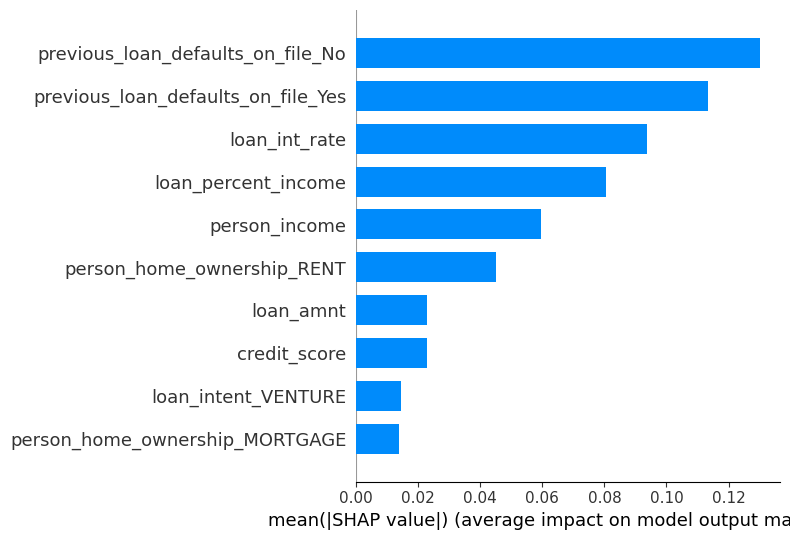

In [17]:
# Sample for speed
X_sample = X_train.sample(min(100, len(X_train)), random_state=42)

# Transform features
X_trans = pipeline.named_steps["preprocess"].transform(X_sample)
rf_model = pipeline.named_steps["model"]

# Get feature names
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][2]
ohe = preprocessor.transformers_[1][1]
cat_feature_names = ohe.get_feature_names_out(cat_features)

final_feature_names = list(num_features) + list(cat_feature_names)

# Convert transformed matrix to DataFrame
X_shap_df = pd.DataFrame(
    X_trans.toarray() if hasattr(X_trans, "toarray") else X_trans,
    columns=final_feature_names
)

# SHAP Explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_df)

# Handle SHAP output format safely
if isinstance(shap_values, list):
    shap_vals = shap_values[1]      # Approved class
else:
    shap_vals = shap_values[:, :, 1]

print("SHAP shape:", shap_vals.shape)
print("Feature matrix shape:", X_shap_df.shape)

# Plot SHAP summary
shap.summary_plot(
    shap_vals,
    X_shap_df,
    plot_type="bar",
    max_display=10
)


In [18]:
df["prediction"] = pipeline.predict(X)

for sensitive in ["gender", "education", "married"]:
    if sensitive in df.columns:
        print(f"\nApproval rate by {sensitive}:")
        print(df.groupby(sensitive)["prediction"].mean())

In [19]:
joblib.dump(pipeline, "loan_approval_model.pkl")
print("\n✅ Model saved as loan_approval_model.pkl")


✅ Model saved as loan_approval_model.pkl


In [20]:
from google.colab import files
files.download("loan_approval_model.pkl")

print("\n🎉 PROJECT EXECUTION COMPLETED SUCCESSFULLY")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 PROJECT EXECUTION COMPLETED SUCCESSFULLY


In [21]:
sample_input = {
    col: X.iloc[0][col] for col in X.columns
}

sample_df = pd.DataFrame([sample_input])
prediction = pipeline.predict(sample_df)

print("Loan Approved ✅" if prediction[0] == 1 else "Loan Rejected ❌")

Loan Approved ✅
